# Maestría en Inteligencia Artificial Aplicada (MNA)**

## Procesamiento de Lenguaje Natural (NLP)**

### Prof. Luis Eduardo Falcón Morales

### Semana 4 - Ejercicios Complementarios**

### Embeddings_Word2Vec

### **NOTA: Estos ejercicios son simplemente para que repases los conceptos de esta semana.**
###**No es una tarea o actividad que debas entregar.**

#### Ejemplo con alguno de los principales métodos Embedding

#### En particular con estos vectores pre-entrenados se puede ilustrar el ejemplo King - man + woman = Queen

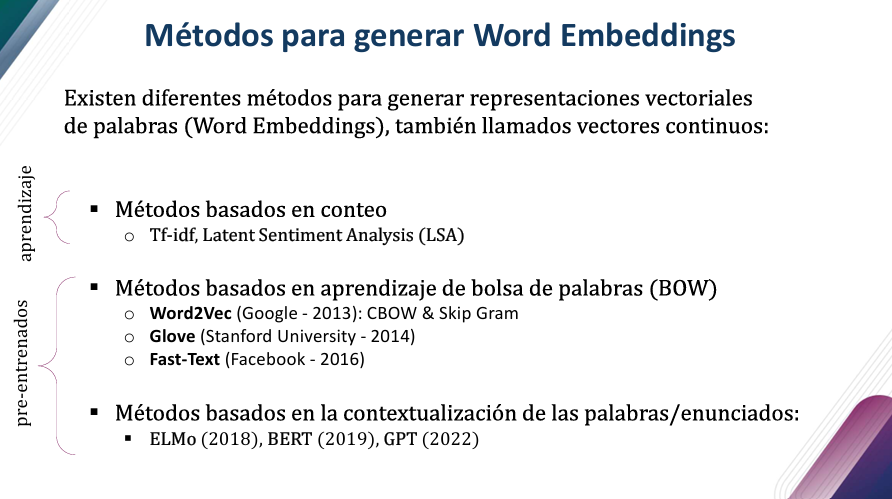

#### Word2Vec - 1st method - Google

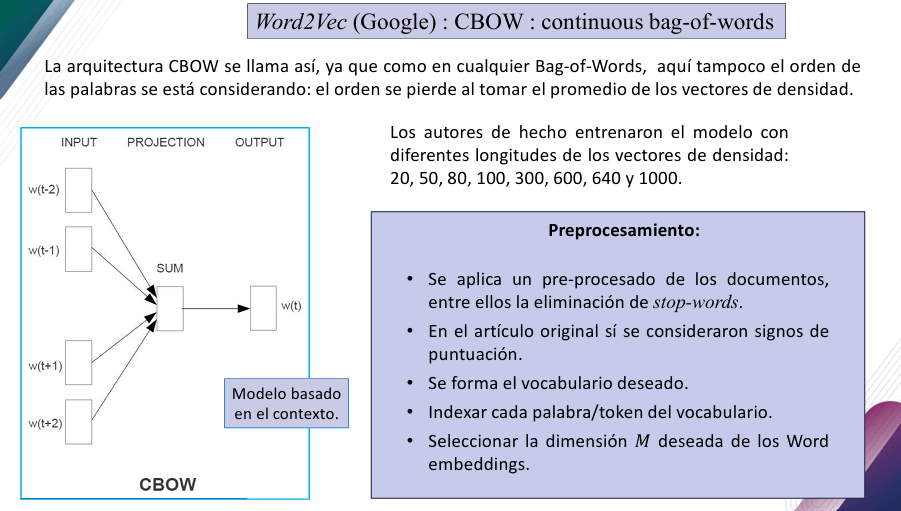

https://code.google.com/archive/p/word2vec/

El descargado de los archivos de los ejemplos que veremos puede llevarse algo de tiempo. El archivo GoogleNews-vectors-negative300.bin.gz de word2vec es de aproximadamente 3.6 GB.

In [1]:
#Primero bajas el archivo de los embeddings Word2Vec:
#!wget https://s3.amazonaws.com/dl4j-distribution/GoogleNews-vectors-negative300.bin.gz

In [2]:
#Y lo descompactas para obtener el binario:
#!gunzip GoogleNews-vectors-negative300.bin

In [3]:
# Para este caso usaremos la librería Gensim: https://radimrehurek.com/gensim/ 

#!pip install gensim

In [ ]:
import gensim

In [ ]:
# Ahora sí cargamos los vectores previamente entrenados por Google... puede tardar un poco en cargarlos...:

model = gensim.models.KeyedVectors.load_word2vec_format(
    '/workspace/micarpeta/misdatos/GoogleNews-vectors-negative300.bin', 
    binary=True
)

In [ ]:
king = model['king']

In [ ]:
print(king.shape)
print(king[0:5])

In [ ]:
# Aquii vamos con el famoso ejemplo: 
#                   king - man + woman = queen

print(model.most_similar(positive=['king', 'woman'], negative=['man']))

In [ ]:
print(model.similarity('woman', 'man'))
print(model.similarity('king', 'woman'))

### GloVe - 2nd method - Standford

In [ ]:
# Aquí usaremos la librería de nlp para los embeddings de Glove:
https://spacy.io/ 

In [ ]:
#!pip install -U spacy

In [ ]:
#!python3 -m spacy download en_core_web_lg

In [ ]:
import spacy
import en_core_web_lg
from scipy.spatial import distance
import numpy as np

In [ ]:
nlp = en_core_web_lg.load()

In [ ]:
# Podemos también introducir todas las palabras involucradas en un enunciado:

doc = nlp("king queen woman man")

In [ ]:
# similaridad entre king y queen:

doc[0].similarity(doc[1])

In [ ]:
# similaridad entre king y woman:
doc[0].similarity(doc[2])

In [ ]:
v =  doc[0].vector - (doc[3].vector*2) + (doc[2].vector*2)

print(v)

In [ ]:
# En lugar de buscar en todo el conjunto de vectores pre-entrenados de GLove, lo buscamos en 
# nuestro enunciado que introducimos al inicio:

vectors = [token.vector for token in doc]
vectors = np.array(vectors)

In [ ]:
print(vectors)   # estos son los vectors 300-dimensionales de nuestras 4 palabras: king, queen, woman man, respectivamente:

In [ ]:
# Ahora buscamos con cual de estos se encuentra más cercano el vector "v=king-man+woman": 

closest_index = distance.cdist(np.expand_dims(v, axis = 0), vectors, metric = 'cosine').argmin()
output_word = doc[closest_index].text

print(output_word)

### FastText - 3rd method - Facebook

https://github.com/facebookresearch/fastText

In [ ]:
#!pip install Cython --install-option="--no-cython-compile"

In [ ]:
#!pip install fasttext

Usaremos el los vectores embedding previamente entrenamos para 157 idiomas:

https://fasttext.cc/docs/en/crawl-vectors.html

https://arxiv.org/abs/1802.06893

In [ ]:
import fasttext
import fasttext.util

In [ ]:
# ... se toma su tiempo... unos 5-10 minutes:

#fasttext.util.download_model('en', if_exists='ignore')  # English

In [ ]:
#fasttext.util.download_model('es', if_exists='ignore')   # Espagnol

In [ ]:
ft = fasttext.load_model('cc.en.300.bin')

In [ ]:
ft.get_word_vector('king')

In [ ]:
ft.get_nearest_neighbors('king')

In [ ]:
ft.get_nearest_neighbors('spider-man')

In [ ]:
ft.get_nearest_neighbors('wonder-woman')  